In [41]:
from pathlib import Path
from typing import Dict
from tqdm import tqdm
import numpy as np

import umap.umap_ as umap
from scipy.spatial.distance import cosine

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader

from neuralhydrology.datasetzoo import get_dataset, camelsus
from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.modelzoo.ealstm import EALSTM
from neuralhydrology.nh_run import start_run
from neuralhydrology.utils.config import Config

In [22]:
run_dir = Path("/home/wuhlmann/BA/test_runs/runs/512_batch_size_2711_095750")

# Initialize model with base paramters from config. 
cfg = Config(run_dir / "config.yml")
ea_lstm = EALSTM(cfg=cfg)

# Load the trained weights into the model. 
weights_path = run_dir / "model_epoch030.pt"
weights = torch.load(str(weights_path), map_location="cuda:0")
ea_lstm.load_state_dict(weights)

# Set to eval, to deactivate dropout.
ea_lstm.to(cfg.device)
ea_lstm.eval()


EALSTM(
  (embedding_net): InputLayer(
    (statics_embedding): Identity()
    (dynamics_embeddings): ModuleList(
      (0): Identity()
    )
  )
  (input_gate): Linear(in_features=29, out_features=256, bias=True)
  (dynamic_gates): _DynamicGates()
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Regression(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=1, bias=True)
    )
  )
)

pass scaler, so scaler from training is used 

create custom config (only for validation), in which a "train_data_file" is loaded, which actually holds all time periods and basins (they also need to be passed as txt and pkl). This config, needs to hold the exact same 

In [23]:
cfg.run_dir = Path("/home/wuhlmann/BA/test_runs/dump")

In [24]:
scaler = load_scaler(run_dir=run_dir)
data_set_101 = get_dataset(cfg=cfg, is_train=False, period="train", scaler=scaler, basin="101")
data_set_102 = get_dataset(cfg=cfg, is_train=False, period="train", scaler=scaler, basin="102")

In [25]:
!nvidia-smi

Mon Dec  1 16:00:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.06              Driver Version: 555.42.06      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  |   00000000:D5:00.0 Off |                    0 |
| N/A   37C    P0             50W /  250W |     553MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [26]:
ds_output = []

for i, ds in enumerate([data_set_101, data_set_102]): 
    
    dataloader = DataLoader(ds, batch_size=10000, shuffle=False, collate_fn=ds.collate_fn, num_workers=cfg.num_workers, pin_memory=True)
    output = []

    with torch.no_grad():
        for data in tqdm(dataloader): 
            for key in data.keys():
                    if key.startswith('x_d'):
                        data[key] = {k: v.to(cfg.device) for k, v in data[key].items()}
                    elif not key.startswith('date'):
                        data[key] = data[key].to(cfg.device)
            out = ea_lstm(data) 
            c_n = out["c_n"].cpu().numpy()
            output.append(c_n)

            del out 
            del data
            torch.cuda.empty_cache()

    ds_output.append(output)

100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


In [28]:
import numpy as np

ordered_states = []

for output in ds_output:
    states = np.vstack(output)
    states = np.vstack(states[:,-1,:])
    print(states.shape)
    states = states[~np.isnan(states).any(axis=1)]
    states.shape

    ordered_states.append(states)

(12410, 256)
(6565, 256)


In [42]:
mean_101 = ordered_states[0].mean(axis=0)
mean_102 = ordered_states[1].mean(axis=0)

print(cosine(mean_101, mean_102))

0.07250977153691163


In [34]:
from sklearn.decomposition import PCA

pca = PCA(0.9,svd_solver='full', random_state=42)

pca_101 = pca.fit_transform(ordered_states[0])
pca_102 = pca.transform(ordered_states[1])

In [52]:
reducer = umap.UMAP(
    n_components=3, 
    n_neighbors=100,
    min_dist=0.5,
    random_state=42
)

states_101 = reducer.fit_transform(pca_101)
#states_102 = reducer.transform(pca_102)

/storage/vast-gfz-hpc-01/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


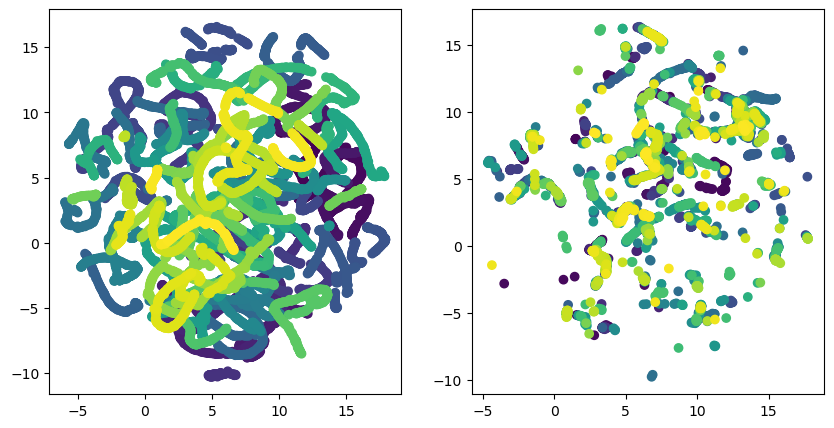

In [44]:
fig, axs = plt.subplots(1,2, figsize=(10,5))

for i,ds in enumerate([states_101, states_102]):

    idx = np.arange(len(ds))
    axs[i].scatter(ds[:,0],ds[:,1], c=idx, cmap="viridis")
    axs[i].title

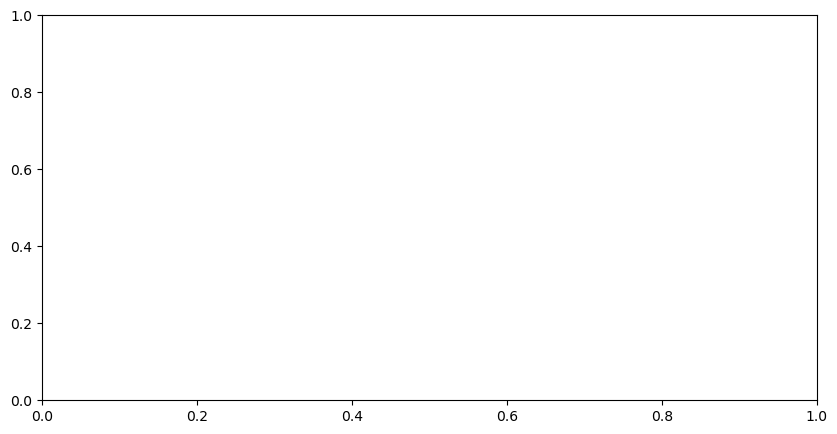

In [50]:
import matplotlib.cm as cm
fig,ax = plt.subplots(1,1, figsize=(10,5))

colors = cm.tab20(np.linspace(0,1, 36))
bin_indices = np.arange(len(states_101)) // 365
point_colors = colors[bin_indices]



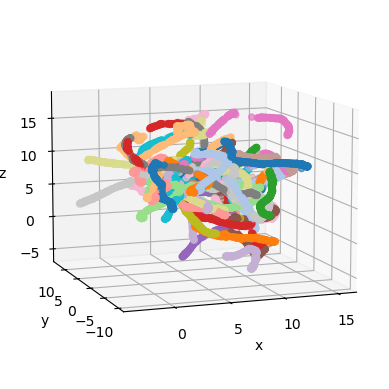

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111,projection="3d")

ax.scatter(states_101[:,0], states_101[:,1],states_101[:,2], c=point_colors)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.view_init(elev=10, azim=250)
plt.show()